# HATR cross-framework — Qualità di regressione

Confronto di `HoeffdingAdaptiveTreeRegressor` in River e CapyMOA su 4 dataset in prequential evaluation, con due configurazioni: deterministica (`mean`, no bootstrap) per misurare la consistenza, e default (`adaptive`, bootstrap) per la qualità realistica.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f"JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn -o package -DskipTests"

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel -> Restart & Run All')
else:
    os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print("Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati")

Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati


## Dataset

In [4]:
MAX_INSTANCES = 17000
SYN_N, SYN_DRIFT = 17000, 5000

import urllib.request, gzip, shutil

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), 'data'))
os.makedirs(DATA_DIR, exist_ok=True)

_ELEC_PATH = os.path.join(DATA_DIR, 'electricity.arff')
_ELEC_URL  = 'https://www.dropbox.com/scl/fi/p7btran9xdas20neva917/electricity.arff.gz?rlkey=xt8hc6542b8wr01eitcw7mwpz&st=paqojdax&dl=1'
if not os.path.exists(_ELEC_PATH):
    print('Downloading electricity.arff...')
    _gz = _ELEC_PATH + '.gz'
    urllib.request.urlretrieve(_ELEC_URL, _gz)
    with gzip.open(_gz, 'rb') as _f_in, open(_ELEC_PATH, 'wb') as _f_out:
        shutil.copyfileobj(_f_in, _f_out)
    os.remove(_gz)
    print('Done.')

datasets = {}
datasets["Synthetic"]         = utils.make_synthetic(n=SYN_N, drift_at=SYN_DRIFT)
datasets["Bike"]              = utils.materialize_stream(Bike(), MAX_INSTANCES)
datasets["Fried"]             = utils.materialize_stream(Fried(), MAX_INSTANCES)
datasets["Hyper"]             = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=2, magnitude_of_change=0.001,
                         noise_percentage=5),
    MAX_INSTANCES)
datasets["HyperFast"]         = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=5, magnitude_of_change=0.1,
                         noise_percentage=10),
    MAX_INSTANCES)
datasets["FriedDrift"]        = utils.make_fried_drift(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["RBFReg"]            = utils.make_rbf_regression(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["ElectricityDemand"] = utils.load_electricity_demand(
    os.path.join(DATA_DIR, 'electricity.arff'), max_instances=MAX_INSTANCES)

for name, (X, y, schema) in datasets.items():
    print(f"{name:<20} n={len(X):>6}  feat={X.shape[1]:>2}  y\u2208[{y.min():.2f}, {y.max():.2f}]")

Synthetic            n= 17000  feat= 5  y∈[-14.29, 15.55]
Bike                 n= 17000  feat=12  y∈[1.00, 977.00]
Fried                n= 17000  feat=10  y∈[-1.23, 30.05]
Hyper                n= 17000  feat=10  y∈[93.98, 677.42]
HyperFast            n= 17000  feat=10  y∈[-4117.78, 11925.45]
FriedDrift           n= 17000  feat=10  y∈[-0.69, 30.15]
RBFReg               n= 17000  feat=10  y∈[-13.18, 16.44]
ElectricityDemand    n= 17000  feat= 7  y∈[0.00, 0.94]


In [5]:
import pandas as pd
import re

def _feat_names(schema, n):
    attrs = re.findall(
        r'@attribute\s+(\S+)\s+({[^}]+}|\S+)',
        str(schema), re.IGNORECASE)
    if len(attrs) >= n:
        return [f'{name} ({"nom" if typ.startswith("{") else "num"})'
                for name, typ in attrs[:n]]
    return [f'x{i}' for i in range(n)]

for name, (X, y, schema) in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name}  —  {len(X)} istanze, {X.shape[1]} feature")
    print(f"  schema: {schema}")
    cols = _feat_names(schema, X.shape[1])
    df = pd.DataFrame(X[:5], columns=cols)
    df['[y]'] = y[:5]
    display(df.round(4))



  Synthetic  —  17000 istanze, 5 feature
  schema: @relation synthetic_drift

@attribute x0 numeric
@attribute x1 numeric
@attribute x2 numeric
@attribute x3 numeric
@attribute x4 numeric
@attribute y numeric

@data


,x0 (num),x1 (num),x2 (num),x3 (num),x4 (num),[y]
0,0.4967,-0.1383,0.6477,1.5230,-0.2342,0.0886
1,-0.2341,1.5792,0.7674,-0.4695,0.5426,3.5357
2,-0.4634,-0.4657,0.2420,-1.9133,-1.7249,-2.7065
3,-0.5623,-1.0128,0.3142,-0.9080,-1.4123,-4.4060
4,1.4656,-0.2258,0.0675,-1.4247,-0.5444,2.1874



  Bike  —  17000 istanze, 12 feature
  schema: @relation bike-share-hour_transform_1

@attribute season numeric
@attribute yr numeric
@attribute mth numeric
@attribute hr numeric
@attribute holiday numeric
@attribute weekday numeric
@attribute workingday numeric
@attribute weathersit numeric
@attribute temp numeric
@attribute atemp numeric
@attribute hum numeric
@attribute windspeed numeric
@attribute cnt numeric

@data


,season (num),yr (num),mth (num),hr (num),holiday (num),weekday (num),workingday (num),weathersit (num),temp (num),atemp (num),hum (num),windspeed (num),[y]
0,1.0,0.0,1.0,0.0,0.0,6.0,0.0,1.0,0.24,0.2879,0.81,0.0,16.0
1,1.0,0.0,1.0,1.0,0.0,6.0,0.0,1.0,0.22,0.2727,0.80,0.0,40.0
2,1.0,0.0,1.0,2.0,0.0,6.0,0.0,1.0,0.22,0.2727,0.80,0.0,32.0
3,1.0,0.0,1.0,3.0,0.0,6.0,0.0,1.0,0.24,0.2879,0.75,0.0,13.0
4,1.0,0.0,1.0,4.0,0.0,6.0,0.0,1.0,0.24,0.2879,0.75,0.0,1.0



  Fried  —  17000 istanze, 10 feature
  schema: @relation data_res_fried.

@attribute attr_0 numeric
@attribute attr_1 numeric
@attribute attr_2 numeric
@attribute attr_3 numeric
@attribute attr_4 numeric
@attribute attr_5 numeric
@attribute attr_6 numeric
@attribute attr_7 numeric
@attribute attr_8 numeric
@attribute attr_9 numeric
@attribute target numeric

@data


...

,x0 (num),x1 (num),x2 (num),x3 (num),x4 (num),x5 (num),x6 (num),x7 (num),x8 (num),x9 (num),[y]
0,0.3745,0.9507,0.7320,0.5987,0.1560,0.1560,0.0581,0.8662,0.6011,0.7081,16.7603
1,0.0206,0.9699,0.8324,0.2123,0.1818,0.1834,0.3042,0.5248,0.4319,0.2912,6.8027
2,0.6119,0.1395,0.2921,0.3664,0.4561,0.7852,0.1997,0.5142,0.5924,0.0465,11.1459
3,0.6075,0.1705,0.0651,0.9489,0.9656,0.8084,0.3046,0.0977,0.6842,0.4402,21.5100
4,0.1220,0.4952,0.0344,0.9093,0.2588,0.6625,0.3117,0.5201,0.5467,0.1849,17.1465



  RBFReg  —  17000 istanze, 10 feature
  schema: @relation rbf_regression

@attribute x0 numeric
@attribute x1 numeric
@attribute x2 numeric
@attribute x3 numeric
@attribute x4 numeric
@attribute x5 numeric
@attribute x6 numeric
@attribute x7 numeric
@attribute x8 numeric
@attribute x9 numeric
@attribute y numeric

@data


,x0 (num),x1 (num),x2 (num),x3 (num),x4 (num),x5 (num),x6 (num),x7 (num),x8 (num),x9 (num),[y]
0,0.2505,0.3464,-0.6800,0.2323,0.2931,-0.7144,1.8658,0.4738,-1.1913,0.6566,2.4634
1,-0.9747,0.7871,1.1586,-0.8207,0.9634,0.4128,0.8221,1.8968,-0.2454,-0.7537,3.2183
2,-0.8895,-0.8158,-0.0771,0.3412,0.2767,0.8272,0.0130,1.4535,-0.2647,2.7202,1.4445
3,0.6257,-0.8572,-1.0709,0.4825,-0.2235,0.7140,0.4732,-0.0728,-0.8468,-1.5148,-0.1328
4,-0.4465,0.8564,0.2141,-1.2457,0.1732,0.3853,-0.8839,0.1537,0.0582,-1.1430,3.1112



  ElectricityDemand  —  17000 istanze, 7 feature
  schema: @relation electricity_demand

@attribute date numeric
@attribute day numeric
@attribute period numeric
@attribute nswprice numeric
@attribute vicprice numeric
@attribute vicdemand numeric
@attribute transfer numeric
@attribute nswdemand numeric

@data


,date (num),day (num),period (num),nswprice (num),vicprice (num),vicdemand (num),transfer (num),[y]
0,0.0,2.0,0.0000,0.0564,0.0035,0.4229,0.4149,0.4392
1,0.0,2.0,0.0213,0.0517,0.0035,0.4229,0.4149,0.4151
2,0.0,2.0,0.0426,0.0515,0.0035,0.4229,0.4149,0.3850
3,0.0,2.0,0.0638,0.0455,0.0035,0.4229,0.4149,0.3146
4,0.0,2.0,0.0851,0.0425,0.0035,0.4229,0.4149,0.2511


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

drift_points = {
    'Synthetic':  SYN_DRIFT,
    'FriedDrift': MAX_INSTANCES // 2,
    'RBFReg':     MAX_INSTANCES // 2,
}

ncols = 3
nrows = -(-len(datasets) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()

for ax, (name, (X, y, _)) in zip(axes, datasets.items()):
    ax.plot(y, color='steelblue', alpha=0.4, linewidth=0.6, label='y')
    window = max(1, len(y) // 50)
    rolling = np.convolve(y, np.ones(window) / window, mode='valid')
    ax.plot(range(window - 1, len(y)), rolling, color='crimson',
            linewidth=1.5, label=f'rolling mean (w={window})')
    if name in drift_points:
        ax.axvline(drift_points[name], color='orange', linestyle='--',
                   linewidth=1.5, label=f'drift @ {drift_points[name]}')
    ax.set_title(name)
    ax.set_xlabel('instance')
    ax.set_ylabel('y')
    ax.legend(fontsize=7)

for ax in axes[len(datasets):]:
    ax.set_visible(False)

fig.suptitle('Dataset overview — target y over time', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Parametri

In [3]:
BASE = dict(grace_period=200, delta=1e-7, tau=0.05, model_selector_decay=0.95,
            drift_window_threshold=300, switch_significance=0.05,
            min_samples_split=5, adwin_delta=0.002, learning_ratio=0.01, seed=0)

CONFIGS = {
    "deterministic (mean, no-bootstrap)": dict(leaf_prediction="mean",     bootstrap_sampling=False),
    "default (adaptive, bootstrap)":      dict(leaf_prediction="adaptive", bootstrap_sampling=True),
}

SCALE = True
SKIP  = 50

## Esecuzione

In [4]:
rows = []
preds_cache = {}   # (dataset, config) -> (yt, river_pred, capy_pred)

CFG = CONFIGS["default (adaptive, bootstrap)"]
# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', CFG, BASE, schema=_w_schema, scale=SCALE)

for ds_name, (X, y, schema) in datasets.items():
    for cfg_name, cfg in CONFIGS.items():
        rp, *_ = utils.prequential_eval(X, y, 'river', cfg, BASE, scale=SCALE)
        cp, *_ = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, scale=SCALE)
        preds_cache[(ds_name, cfg_name)] = (y, rp, cp)
        rows.append(dict(dataset=ds_name, config=cfg_name, framework="River",
                         MAE=utils.mae(y[SKIP:], rp[SKIP:]),
                         RMSE=utils.rmse(y[SKIP:], rp[SKIP:]),
                         R2=utils.r2(y[SKIP:], rp[SKIP:])))
        rows.append(dict(dataset=ds_name, config=cfg_name, framework="CapyMOA",
                         MAE=utils.mae(y[SKIP:], cp[SKIP:]),
                         RMSE=utils.rmse(y[SKIP:], cp[SKIP:]),
                         R2=utils.r2(y[SKIP:], cp[SKIP:])))
        print(f"  {ds_name:<10} | {cfg_name:<32} | done")

results = pd.DataFrame(rows)
print("\nRisultati completi:")
results

  Synthetic  | deterministic (mean, no-bootstrap) | done
  Synthetic  | default (adaptive, bootstrap)    | done
  Bike       | deterministic (mean, no-bootstrap) | done
  Bike       | default (adaptive, bootstrap)    | done
  Fried      | deterministic (mean, no-bootstrap) | done
  Fried      | default (adaptive, bootstrap)    | done
  Hyper      | deterministic (mean, no-bootstrap) | done
  Hyper      | default (adaptive, bootstrap)    | done
  HyperFast  | deterministic (mean, no-bootstrap) | done
  HyperFast  | default (adaptive, bootstrap)    | done
  FriedDrift | deterministic (mean, no-bootstrap) | done
  FriedDrift | default (adaptive, bootstrap)    | done
  RBFReg     | deterministic (mean, no-bootstrap) | done
  RBFReg     | default (adaptive, bootstrap)    | done
  ElectricityDemand | deterministic (mean, no-bootstrap) | done
  ElectricityDemand | default (adaptive, bootstrap)    | done

Risultati completi:


,dataset,config,framework,MAE,RMSE,R2
0,Synthetic,"deterministic (mean, no-bootstrap)",River,0.936824,1.527062,0.786956
1,Synthetic,"deterministic (mean, no-bootstrap)",CapyMOA,0.936824,1.527062,0.786956
2,Synthetic,"default (adaptive, bootstrap)",River,0.295454,0.526002,0.974723
3,Synthetic,"default (adaptive, bootstrap)",CapyMOA,0.291272,0.518307,0.975457
4,Bike,"deterministic (mean, no-bootstrap)",River,85.401484,123.432798,0.540721
5,Bike,"deterministic (mean, no-bootstrap)",CapyMOA,85.401484,123.432798,0.540721
6,Bike,"default (adaptive, bootstrap)",River,73.095524,113.001145,0.615071
7,Bike,"default (adaptive, bootstrap)",CapyMOA,69.408531,110.818854,0.629795
8,Fried,"deterministic (mean, no-bootstrap)",River,2.493060,3.120926,0.608514
9,Fried,"deterministic (mean, no-bootstrap)",CapyMOA,2.493060,3.120926,0.608514


## Qualità

In [5]:
pivot = results.pivot_table(index=["dataset", "config"], columns="framework",
                            values=["MAE", "RMSE", "R2"])
pivot = pivot.reorder_levels([1, 0], axis=1).sort_index(axis=1)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pivot

framework                                              CapyMOA         \
                                                           MAE     R2   
dataset           config                                                
Bike              default (adaptive, bootstrap)        69.4085 0.6298   
                  deterministic (mean, no-bootstrap)   85.4015 0.5407   
ElectricityDemand default (adaptive, bootstrap)         0.0525 0.6540   
                  deterministic (mean, no-bootstrap)    0.0711 0.6537   
Fried             default (adaptive, bootstrap)         1.8661 0.7690   
                  deterministic (mean, no-bootstrap)    2.4931 0.6085   
FriedDrift        default (adaptive, bootstrap)         1.9810 0.7322   
                  deterministic (mean, no-bootstrap)    2.7738 0.5093   
Hyper             default (adaptive, bootstrap)         9.8627 0.9360   
                  deterministic (mean, no-bootstrap)   46.6526 0.3063   
HyperFast         default (adaptive, bootstrap)       260.7936 0.9735   
                  deterministic (mean, no-bootstrap) 1163.2251 0.6382   
RBFReg            default (adaptive, bootstrap)         2.0556 0.2264   
                  deterministic (mean, no-bootstrap)    2.1694 0.1755   
Synthetic         default (adaptive, bootstrap)         0.2913 0.9755   
                  deterministic (mean, no-bootstrap)    0.9368 0.7870   

framework                                                          River  \
                                                          RMSE       MAE   
dataset           config                                                   
Bike              default (adaptive, bootstrap)       110.8189   73.0955   
                  deterministic (mean, no-bootstrap)  123.4328   85.4015   
ElectricityDemand default (adaptive, bootstrap)         0.0917    0.0544   
                  deterministic (mean, no-bootstrap)    0.0917    0.0711   
Fried             default (adaptive, bootstrap)         2.3971    1.8270   
                  deterministic (mean, no-bootstrap)    3.1209    2.4931   
FriedDrift        default (adaptive, bootstrap)         2.5671    2.0213   
                  deterministic (mean, no-bootstrap)    3.4751    2.7738   
Hyper             default (adaptive, bootstrap)        17.7371    8.4238   
                  deterministic (mean, no-bootstrap)   58.3844   46.6526   
HyperFast         default (adaptive, bootstrap)       399.5462  247.0676   
                  deterministic (mean, no-bootstrap) 1476.5575 1163.2251   
RBFReg            default (adaptive, bootstrap)         2.6738    2.1180   
                  deterministic (mean, no-bootstrap)    2.7604    2.1694   
Synthetic         default (adaptive, bootstrap)         0.5183    0.2955   
                  deterministic (mean, no-bootstrap)    1.5271    0.9368   

framework                                                               
                                                          R2      RMSE  
dataset           config                                                
Bike              default (adaptive, bootstrap)       0.6151  113.0011  
                  deterministic (mean, no-bootstrap)  0.5407  123.4328  
ElectricityDemand default (adaptive, bootstrap)      -5.7031    0.4036  
                  deterministic (mean, no-bootstrap)  0.6537    0.0917  
Fried             default (adaptive, bootstrap)       0.7770    2.3556  
                  deterministic (mean, no-bootstrap)  0.6085    3.1209  
FriedDrift        default (adaptive, bootstrap)       0.7191    2.6296  
                  deterministic (mean, no-bootstrap)  0.5093    3.4751  
Hyper             default (adaptive, bootstrap)       0.9476   16.0489  
                  deterministic (mean, no-bootstrap)  0.3063   58.3844  
HyperFast         default (adaptive, bootstrap)       0.9743  393.6611  
                  deterministic (mean, no-bootstrap)  0.6382 1476.5575  
RBFReg            default (adaptive, bootstrap)       0.1892    2.7374  

## Grafici

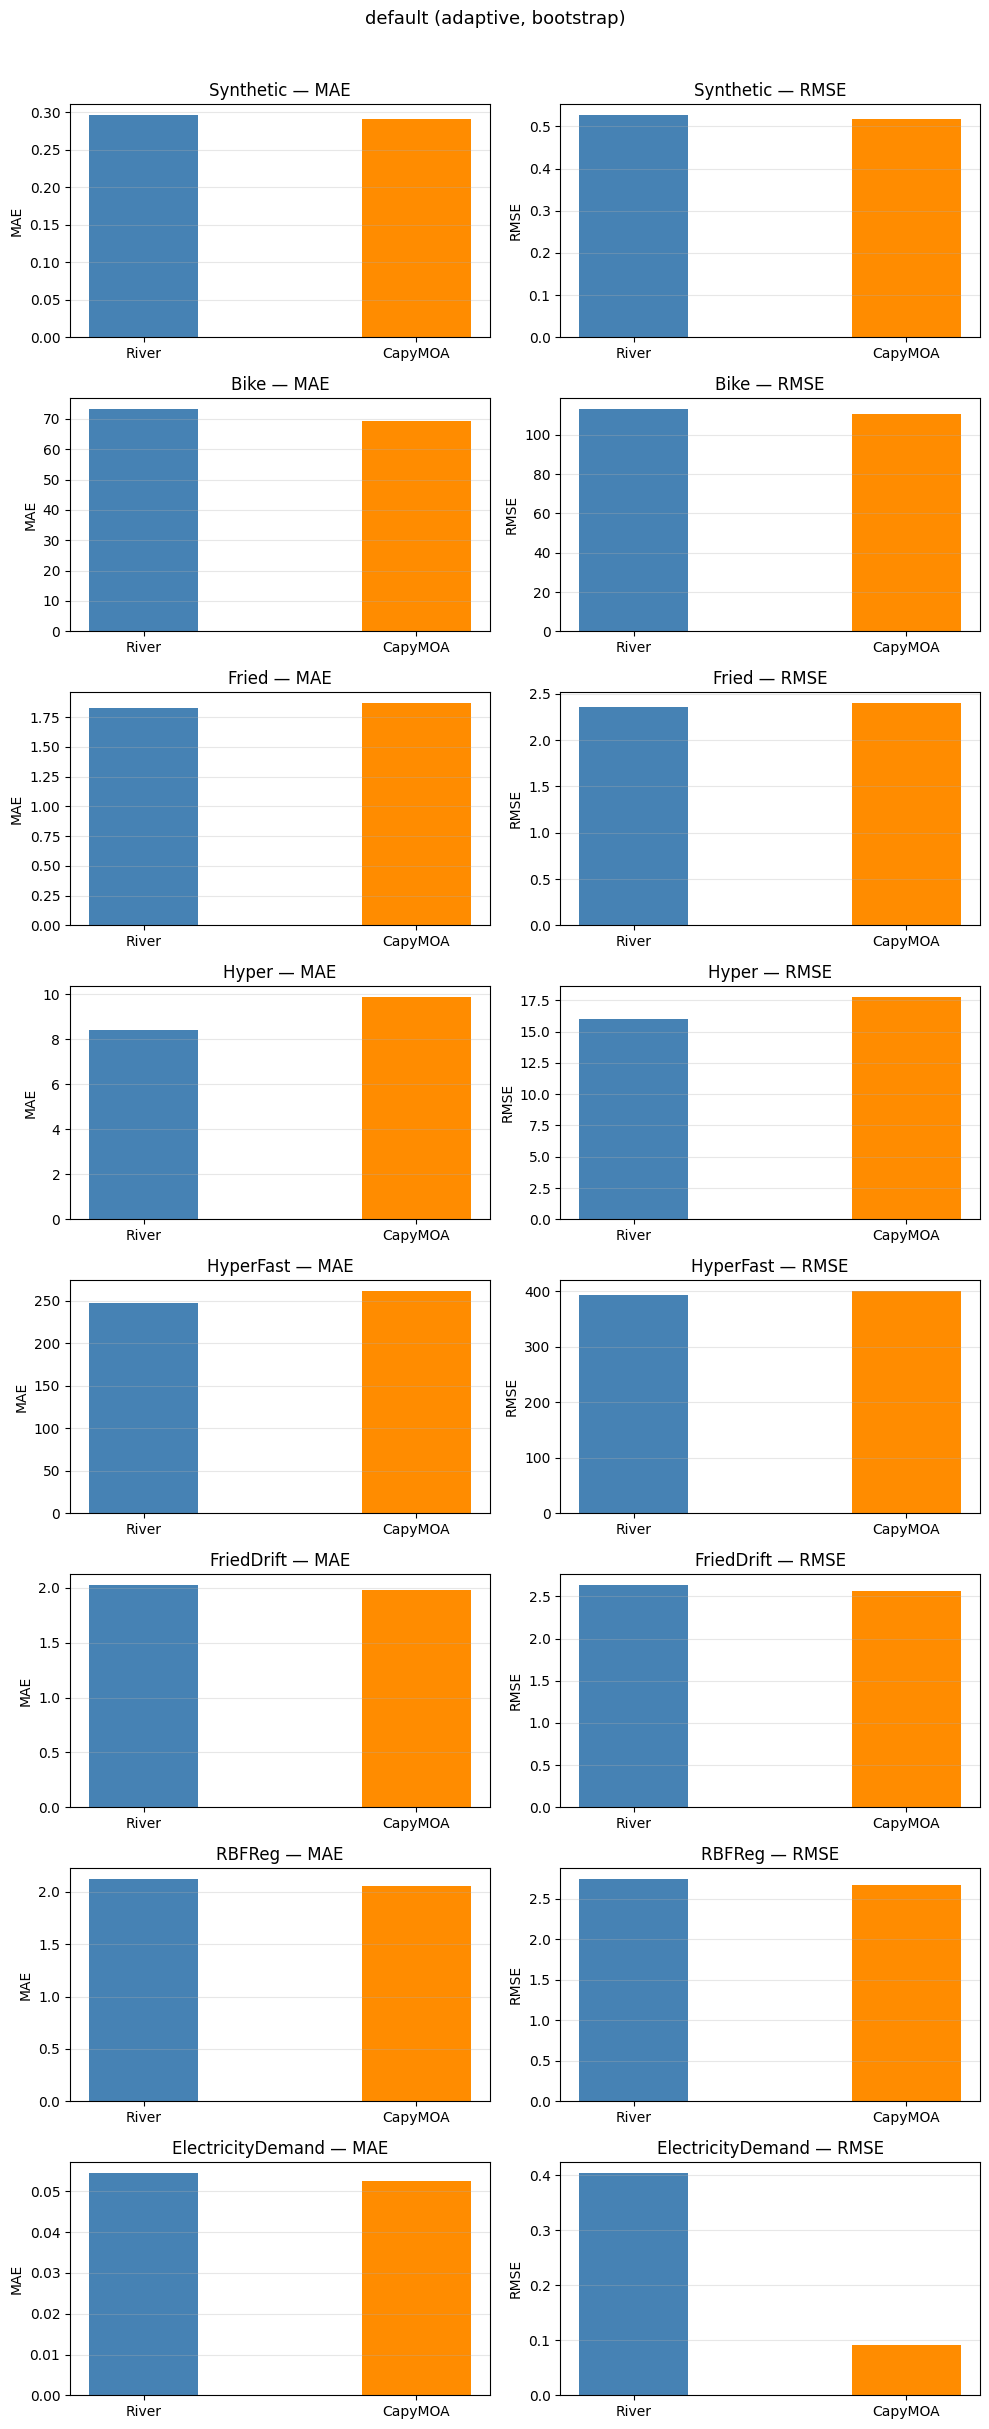

In [12]:
cfg_plot = "default (adaptive, bootstrap)"
sub      = results[results.config == cfg_plot]
ds_order = list(datasets.keys())
metrics  = ["MAE", "RMSE"]
colors   = {"River": "steelblue", "CapyMOA": "darkorange"}

fig, axes = plt.subplots(len(ds_order), 2,
                         figsize=(10, 3 * len(ds_order)),
                         squeeze=False)

for row, ds in enumerate(ds_order):
    ds_sub = sub[sub.dataset == ds]
    for col, metric in enumerate(metrics):
        ax  = axes[row, col]
        rv  = ds_sub[ds_sub.framework == "River"][metric].values[0]
        cm  = ds_sub[ds_sub.framework == "CapyMOA"][metric].values[0]
        ax.bar([0], [rv], 0.4, label="River",   color=colors["River"])
        ax.bar([1], [cm], 0.4, label="CapyMOA", color=colors["CapyMOA"])
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["River", "CapyMOA"])
        ax.set_ylabel(metric)
        ax.set_title(f"{ds} — {metric}")
        ax.grid(alpha=0.3, axis="y")

fig.suptitle(cfg_plot, fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Consistenza (deterministico)

In [7]:
cfg_det = "deterministic (mean, no-bootstrap)"
cons = []
for ds_name in datasets.keys():
    yt, rp, cp = preds_cache[(ds_name, cfg_det)]
    d = np.abs(rp - cp)
    corr = np.corrcoef(rp[SKIP:], cp[SKIP:])[0, 1]
    cons.append(dict(dataset=ds_name,
                     corr=corr, max_abs_diff=d.max(), mean_abs_diff=d.mean(),
                     frac_diff_lt_1e6=float(np.mean(d < 1e-6)),
                     MAE_river=utils.mae(yt[SKIP:], rp[SKIP:]),
                     MAE_capy=utils.mae(yt[SKIP:], cp[SKIP:]),
                     dMAE=abs(utils.mae(yt[SKIP:], rp[SKIP:]) - utils.mae(yt[SKIP:], cp[SKIP:]))))
cons_df = pd.DataFrame(cons)
print("Consistenza (mean, no bootstrap):")
cons_df

Consistenza (mean, no bootstrap):


,dataset,corr,max_abs_diff,mean_abs_diff,frac_diff_lt_1e6,MAE_river,MAE_capy,dMAE
0,Synthetic,1.0000,0.0000,0.0000,1.0000,0.9368,0.9368,0.0000
1,Bike,1.0000,0.0000,0.0000,1.0000,85.4015,85.4015,0.0000
2,Fried,1.0000,0.0000,0.0000,1.0000,2.4931,2.4931,0.0000
3,Hyper,1.0000,0.0000,0.0000,1.0000,46.6526,46.6526,0.0000
4,HyperFast,1.0000,0.0000,0.0000,1.0000,1163.2251,1163.2251,0.0000
5,FriedDrift,1.0000,0.0000,0.0000,1.0000,2.7738,2.7738,0.0000
6,RBFReg,1.0000,0.0000,0.0000,1.0000,2.1694,2.1694,0.0000
7,ElectricityDemand,1.0000,0.0000,0.0000,1.0000,0.0711,0.0711,0.0000


## Discussione

**Modalità deterministica (`mean`, no bootstrap).** Le implementazioni condividono lo stesso algoritmo; ci si aspettano predizioni identiche (corr ≈ 1, delta_MAE ≈ 0).

**Modalità default (`adaptive` + bootstrap).** Le RNG divergono (Python MT vs `java.util.Random`): le predizioni puntuali non coincidono, ma MAE/RMSE aggregati restano vicini. Per valutare la qualità reale è questo il confronto corretto.

**Standardizzazione.** `SCALE=True` applica lo stesso `StandardScaler` online a entrambi i lati; non introduce asimmetrie.